In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.dates as mdates

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima


In [3]:
data_full = pd.read_csv("merged_data.csv")
data_full.set_index('time',inplace=True)
data_full.index = pd.to_datetime(data_full.index)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
time,,,,,,,,,,,,,,,,,,,,,
2011-12-26 21:00:00+00:00,63.0,66.94,64.0,40.08,NaN,118.51,147.69,0.7,77.48,229.39,...,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-26 22:00:00+00:00,64.0,67.00,64.0,39.99,NaN,116.11,144.47,0.7,78.37,224.55,...,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-26 23:00:00+00:00,64.0,67.00,64.0,40.08,NaN,114.61,142.83,0.7,78.58,221.84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
data_full.drop(data_full[data_full['VSD power frequency'] < 7].index,inplace=True)
data_full.drop(data_full[pd.isna(data_full['VSD power frequency'])].index,inplace=True)

69
3.17515925662796
2.559304672339307
2.4262577571019115
1.235793483857164
0.9719320966177232
2.8324888353371374
15.04519315328347
2.3167178830455226
2.5739641974144867
0.8808005427041857
2.178535274674064
0.5576599403992033
2.0569375425306555
5.962743006927823
0.9550496777684663
1.6554507130966079
3.785600629416095
0.03742175238253748
6.457719411680875
2.081283381798566
6.343813020933726
5.1310156889255385
1.9432753992475937
2.0159280491050264
2.6418603805294834
1.2947224121525374
1.3082619379335374
1.4217541631662076
1.7253144471996245
3.741234215708783
3.948033759283471
7.329279057470038
1.99321981749324
3.4212629367473357
4.017072780354081
5.380122928639527
2.443800628146435
4.01903668167895
3.2515837029746977
1.5636923834490268
2.116383371640775
6.376582863023817
0.045090565243027764
1.0882935568449799
2.7920939486138674
7.093794772143604
0.36350497589810443
3.726765531067723
2.7070753710568916
1.2910351128140012
2.473433480577677
0.2740020120650471
0.1140323222713947
0.0486343047

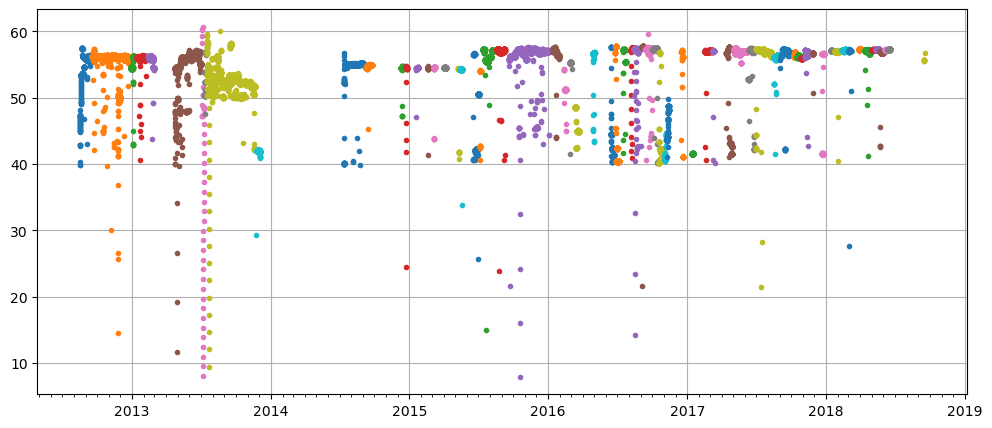

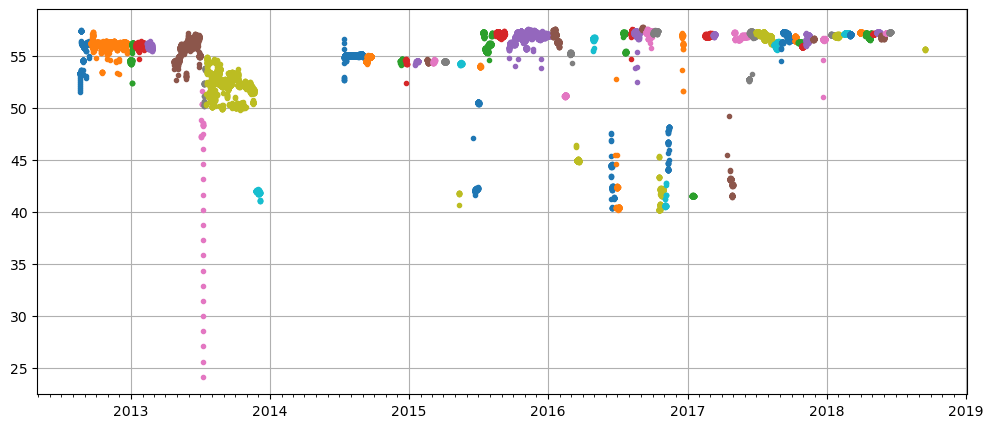

In [8]:
# Dividing data by month

vsd_name = 'VSD power frequency'
data_name = 'ESP discharge pressure'
well_ids = np.unique(data_full['Well Run'])
#well_ids = pvals[pvals[data_name]>0.05].index

#well = np.random.choice(well_ids,1,replace=False)
#well = ['A-21 2']

data = data_full[data_full['Well Run'] ==well[0]][vsd_name]

#year = np.random.choice(data.index.year)
#month = np.random.choice(data.index[data.index.year==year].month)

year1 = np.min(data.index.year)
month1 = np.min(data.index[data.index.year==year1].month)

year2 = np.max(data.index.year)
month2 = np.max(data.index[data.index.year==year2].month)+1
if month2 == 13:
    month2 = 1
    year2 += 1


#vsd = data[np.logical_and(np.logical_and(np.logical_and(data.index.month==month, data.index.year==year), data.index.day>=day1), data.index.day<=day2)]
vsd = data.copy()
vsd.index = vsd.index.tz_localize(None)


first = datetime(year1, month1, 1, 0, 0, 0)
last = datetime(year2, month2, 1, 0, 0, 0)
delta = timedelta(hours = 1)

dates = pd.date_range(start=first, end=last, freq='H')

#dates = (first + delta * x for x in range(31 * 24))


days = pd.DataFrame(index = dates,
                   data = np.zeros(dates.size))


days.loc[vsd.index,0] = 1


# Dividing by groups

datesize = 1

a = vsd.index[vsd.index.to_series().diff().dt.days>datesize]

blcks = [None]*(a.size+1)
nblcs = 0



if a.size == 0:
    b = vsd
    blcks[nblcs] = b
    nblcs = 1

else:
    for i in range(a.size):
        
        if i>0:
            b =  vsd.loc[np.logical_and(vsd.index<a[i],vsd.index>=a[i-1])]
        else:
            b = vsd.loc[vsd.index<a[i]]
    
        if b.size > 0: 
            if (b.index[-1]-b.index[0]).days > datesize:
                blcks[nblcs] = b
                nblcs += 1

    b =  vsd.loc[vsd.index>=a[i]]
    if b.size > 0:
        if (b.index[-1]-b.index[0]).days > datesize:
            blcks[nblcs] = b
            nblcs += 1


plt.figure()
print(nblcs)
for i in range(nblcs):
    b = blcks[i]
    mn = b.mean()
    md = b.median()
    st = b.std()
    
    qt= (b-md).abs().quantile(q=0.90)

    print(st)

    c = b.drop(b[np.abs(b-mn)>1*st].index,inplace=False)
    #c = b.drop(b[np.abs(b-md)>qt].index,inplace=False)
    
    plt.figure(1)
    plt.plot(b,'.')

    plt.figure(2)
    plt.plot(c,'.')


for i in [1,2]:
    plt.figure(i)
    plt.grid(True)
    plt.gcf().set_size_inches(12,5)
    plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())

#from statsmodels.tsa.deterministic import TimeTrend
#trend_gen = TimeTrend(True, 1)
#trend_gen.in_sample(vsd.index)
#trend_gen.in_sample(vsd)

Means: [[60.97550459]
 [61.58175676]] 
 Standard Deviations: [[[0.0880787 ]]

 [[0.02502583]]] 
 Weights: [0.74657535 0.25342465]


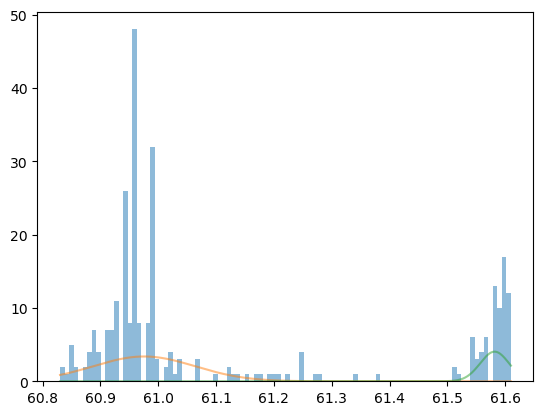

In [215]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

gmm = GaussianMixture(n_components=2)

b = blcks[1]
mn = b.mean()
md = b.median()
st = b.std()
qt= (b-md).abs().quantile(q=0.90)

c = b.drop(b[np.abs(b-mn)>1*st].index,inplace=False)

plt.hist(c, bins=100, alpha=0.5);

gmm.fit(c.values.reshape(-1, 1));

means = gmm.means_
standard_deviations = gmm.covariances_**0.5  
weights = gmm.weights_  


print(f"Means: {means} \n Standard Deviations: {standard_deviations} \n Weights: {weights}")

x = np.linspace(min(c), max(c), 1000)
for mean, std, weight in zip(means, standard_deviations, weights):
    pdf = weight*norm.pdf(x, mean, std) * 1
    plt.plot(x.reshape(-1, 1), pdf.reshape(-1, 1), alpha=0.5)

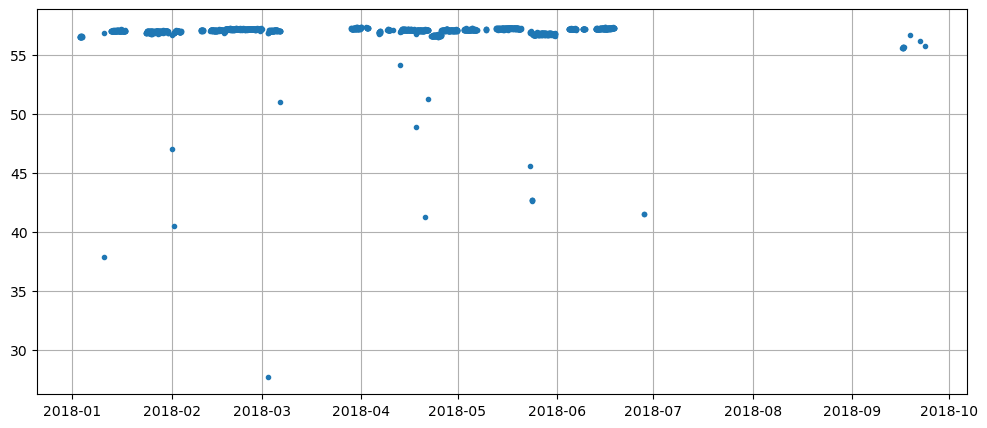

In [9]:
data_name = 'VSD power frequency'
well_ids = np.unique(data_full['Well Run'])
#well_ids = pvals[pvals[data_name]>0.05].index

#well = np.random.choice(well_ids,1,replace=False)

data = data_full[data_full['Well Run'] ==well[0]][data_name]

year = np.random.choice(data.index.year)

day1 = 1
day2 = 31


monthly = data[data.index.year==year]
monthly.index = monthly.index.tz_localize(None)
#data_full[]
plt.figure()
plt.plot(monthly,'.')
plt.grid(True)
plt.gcf().set_size_inches(12,5)




NameError: name 'ht' is not defined

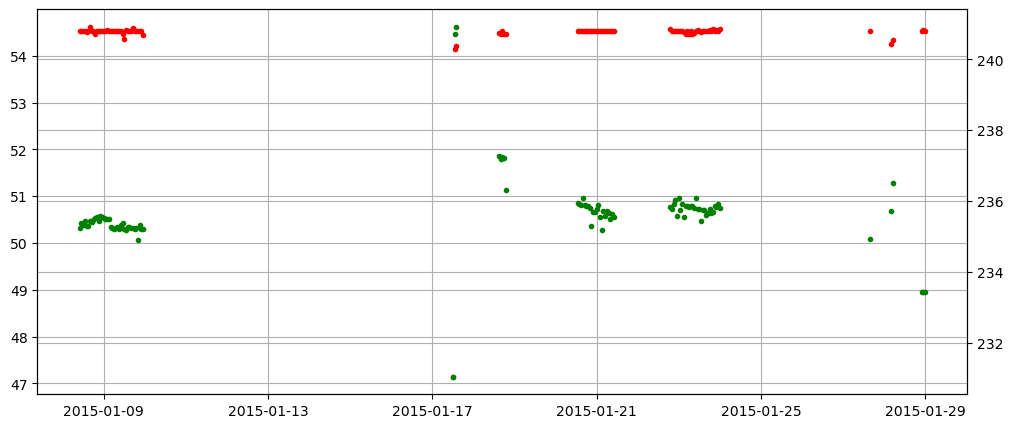

In [6]:
vsd_name = 'VSD power frequency'
data_name = 'ESP discharge pressure'
well_ids = np.unique(data_full['Well Run'])
#well_ids = pvals[pvals[data_name]>0.05].index

#well = np.random.choice(well_ids,1,replace=False)

data = data_full[data_full['Well Run'] ==well[0]][vsd_name]

year = np.random.choice(data.index.year)
month = np.random.choice(data.index[data.index.year==year].month)

day1 = 1
day2 = 31


vsd = data[np.logical_and(np.logical_and(np.logical_and(data.index.month==month, data.index.year==year), data.index.day>=day1), data.index.day<=day2)]
vsd.index = vsd.index.tz_localize(None)
#data_full[]
plt.figure()
plt.plot(vsd,'r.')
plt.grid(True)
plt.gcf().set_size_inches(12,5)

data = data_full[data_full['Well Run'] ==well[0]][data_name]



monthly= data[np.logical_and(np.logical_and(np.logical_and(data.index.month==month, data.index.year==year), data.index.day>=day1), data.index.day<=day2)]
monthly.index = monthly.index.tz_localize(None)
plt.gca().twinx()
plt.plot(monthly,'g.')
plt.grid(True)
plt.gcf().set_size_inches(12,5)


plt.plot(monthly.index,ht*vsd.mean(),'y.')
plt.grid(True)
plt.gcf().set_size_inches(12,5)

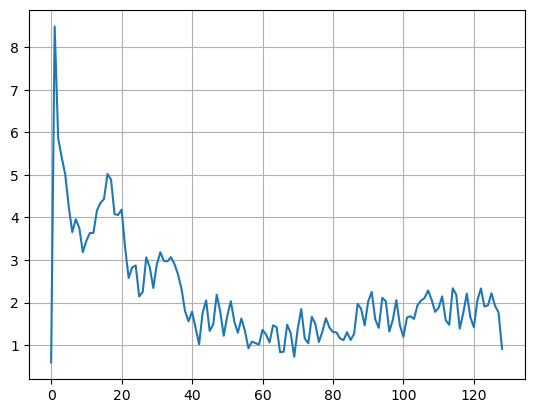

In [11]:
from scipy.signal import welch, csd, bode

x = vsd.copy()
y = monthly.copy()

# Calculate the power spectral densities of the input and output signals.
pxx = welch(x)
pyy = welch(y)
# Calculate the cross-spectral density between the input and output signals.
pxy = csd(x, y)
pyx = csd(y, x)

# Convert the cross-spectral density so that it plays nice with numpy
pxy = np.asarray(pxy)
pyx = np.asarray(pyx)

#Convert input and output power spectral destines to np arrays so we can divide them laer
pxx = np.asarray(pxx)
pyy = np.asarray(pyy)
f = pxx[0,:]
pxx = pxx[1,:]
pyy = pyy[1,:]
pxy = pxy[1,:]
pyx = pyx[1,:]

# Calculate the ratio of the cross-spectral density to the power spectral density
# of the input signal.
plt.figure()
h1 = np.divide(pyx, pxx)
h2 = np.divide(pyy, pxy)

ht = sp.fft.ifft(h1)

#plt.plot(np.abs(h1))
#plt.plot(np.abs(pxx))
plt.plot(np.abs(pyy))
#plt.plot(np.abs(pxy))
plt.grid(True)



NameError: name 'ct' is not defined

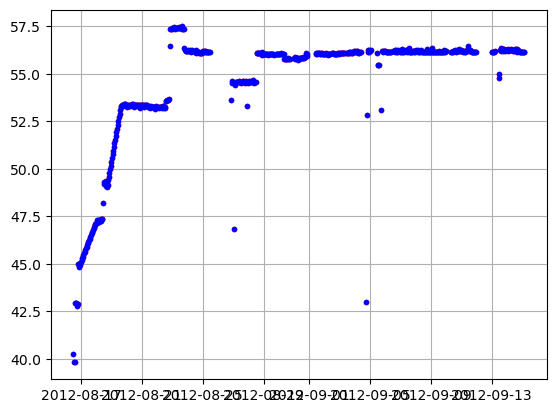

In [12]:
b = blcks[0]

t = b.index

x = b

dat_data = data_full[data_full['Well Run'] ==well[0]][data_name]
dat_data.index = dat_data.index.tz_localize(None)
y = dat_data[t]

plt.figure()
plt.plot(y,'.r')
plt.plot(x,'.b')

pxx = welch(x)
pyy = welch(y)
pxy = csd(x, y)
pyx = csd(y, x)

pxy = np.asarray(pxy)
pyx = np.asarray(pyx)
pxx = np.asarray(pxx)
pyy = np.asarray(pyy)

f = pxx[0,:]
pxx = pxx[1,:]
pyy = pyy[1,:]
pxy = pxy[1,:]
pyx = pyx[1,:]

#plt.figure()
h1 = np.divide(pyx, pxx)
h2 = np.divide(pyy, pxy)


#plt.semilogy(np.abs(h1))
#plt.plot(np.abs(h2))
#plt.semilogy(f,np.abs(h1))
#plt.semilogy(np.abs(sp.fft.fft(x.values))[:x.size//2])
plt.grid(True)

s = ct.frd(h1,f,name='a')
s.plot('bode')


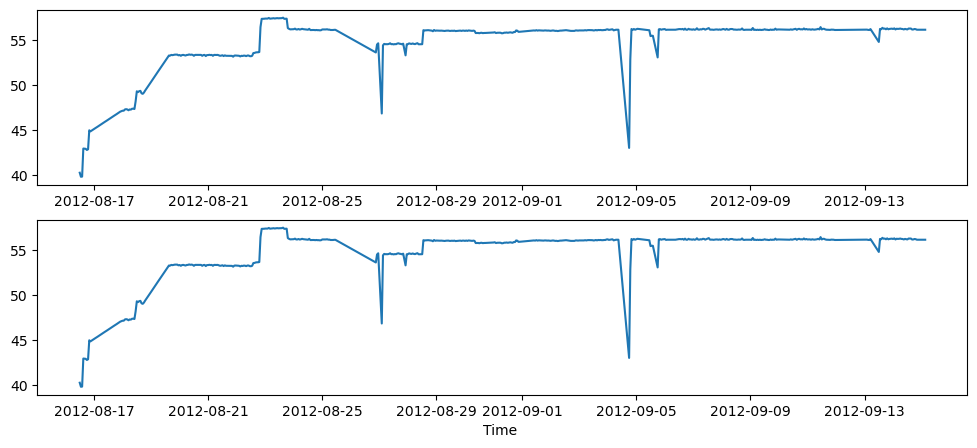

586

In [13]:
#from gekko import GEKKO

#na = 30
#nb = 8

#m = GEKKO(remote=False)

#nt = int(x.size*0.8)
#tt = t[:nt]
#xt = x[:nt]
#yt = y[:nt]

#yp,p,K = m.sysid(tt,xt,yt,na,nb,pred='meas')

#m = GEKKO(remote=False)
#ya,ua = m.arx(p)

#m.time = t.values
#ua[0].value = x.values
#ya[0].value = y[0]
#m.options.imode = 4
#m.options.nodes = 2
#m.solve(disp=False)



plt.figure()
plt.subplot(2,1,1)
plt.plot(t,x)
plt.subplot(2,1,2)
plt.plot(t,y)
plt.xlabel('Time ')
plt.gcf().set_size_inches(12,5)
plt.show()

x.size

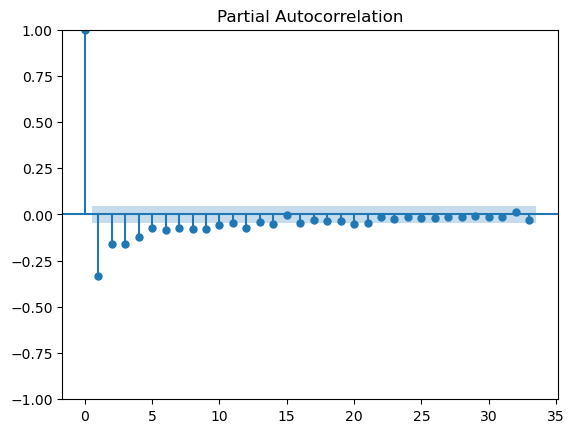

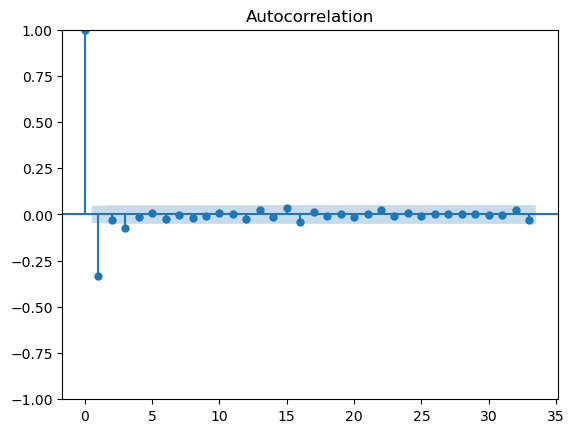

In [643]:
plot_pacf(np.diff(yt));
plot_acf(np.diff(yt));

In [14]:
xord = 3

# Getting data




nt = int(x.size*0.8)
tt = t[:nt]
xt = x[:nt].shift(range(xord),fill_value=0).values
yt = y[:nt]

ord = (20,1,3)

mod = ARIMA(order=ord,trend='ct',with_intercept=True)
#mod = sm.tsa.SARIMAX(endog=sim,order=(1,0,1),trend='c').fit(disp=0)
res = mod.fit(yt,X=xt,disp=0)

res.summary()

/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  468
Model:              SARIMAX(20, 1, 3)   Log Likelihood                4936.798
Date:                Mon, 23 Sep 2024   AIC                          -9815.596
Time:                        14:21:46   BIC                          -9695.352
Sample:                             0   HQIC                         -9768.276
                                - 468                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -2.794e-17   4.81e-26  -5.81e+08      0.000   -2.79e-17   -2.79e-17
drift       8.493e-20   3.89e-25   2.18e+05      0.000    8.49e-20    8.49e-20
x1             1.0000   1.26e-24   7.96e+23      0.000       1.000       1.000
x2         -7.026e-17   1.99e-24  -3.53e+07      0.000   -7.03e-17   -7.03e-17
x3         -6.939e-18   9.45e-25  -7.34e+06      0.000   -6.94e-18   -6.94e-18
ar.L1      -3.461e-39   3.99e-22  -8.67e-18      1.000   -7.82e-22    7.82e-22
ar.L2       -3.45e-39   4.46e-34  -7.74e-06      1.000   -8.74e-34    8.74e-34
ar.L3       -3.48e-39   4.85e-32  -7.18e-08      1.000   -9.51e-32    9.51e-32
ar.L4      -3.522e-39   8.39e-32   -4.2e-08      1.000   -1.64e-31    1.64e-31
ar.L5      -3.548e-39   7.13e-31  -4.98e-09      1.000    -1.4e-30     1.4e-30
ar.L6      -3.582e-39   9.92e-31  -3.61e-09      1.000   -1.95e-30    1.95e-30
ar.L7      -3.626e-39   3.55e-31  -1.02e-08      1.000   -6.96e-31    6.96e-31
ar.L8      -3.654e-39   3.07e-30  -1.19e-09      1.000   -6.01e-30    6.01e-30
ar.L9      -3.713e-39   2.93e-30  -1.27e-09      1.000   -5.75e-30    5.75e-30
ar.L10     -3.753e-39   1.28e-31  -2.93e-08      1.000   -2.51e-31    2.51e-31
ar.L11     -3.788e-39   1.32e-30  -2.88e-09      1.000   -2.58e-30    2.58e-30
ar.L12     -3.588e-39   8.49e-30  -4.23e-10      1.000   -1.66e-29    1.66e-29
ar.L13     -4.342e-39   7.23e-30     -6e-10      1.000   -1.42e-29    1.42e-29
ar.L14     -4.424e-39   4.95e-30  -8.93e-10      1.000   -9.71e-30    9.71e-30
ar.L15     -4.342e-39   6.57e-30  -6.61e-10      1.000   -1.29e-29    1.29e-29
ar.L16     -4.333e-39   4.66e-30   -9.3e-10      1.000   -9.13e-30    9.13e-30
ar.L17     -4.158e-39   5.27e-30  -7.89e-10      1.000   -1.03e-29    1.03e-29
ar.L18      -5.27e-39   1.67e-30  -3.16e-09      1.000   -3.27e-30    3.27e-30
ar.L19     -5.055e-39   4.08e-31  -1.24e-08      1.000   -7.99e-31    7.99e-31
ar.L20      -2.48e-39   1.15e-30  -2.16e-09      1.000   -2.25e-30    2.25e-30
ma.L1      -9.697e-39   3.99e-22  -2.43e-17      1.000   -7.82e-22    7.82e-22
ma.L2      -9.746e-39   6.21e-38     -0.157      0.875   -1.31e-37    1.12e-37
ma.L3      -9.842e-39   4.04e-38     -0.244      0.807    -8.9e-38    6.93e-38
sigma2          1e-10   9.18e-11      1.089      0.276   -7.99e-11     2.8e-10
===================================================================================
Ljung-Box (L1) (Q):                  32.58   Jarque-Bera (JB):              9060.79
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.75   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                        24.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.43e+73. Standard errors may be unsta

/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


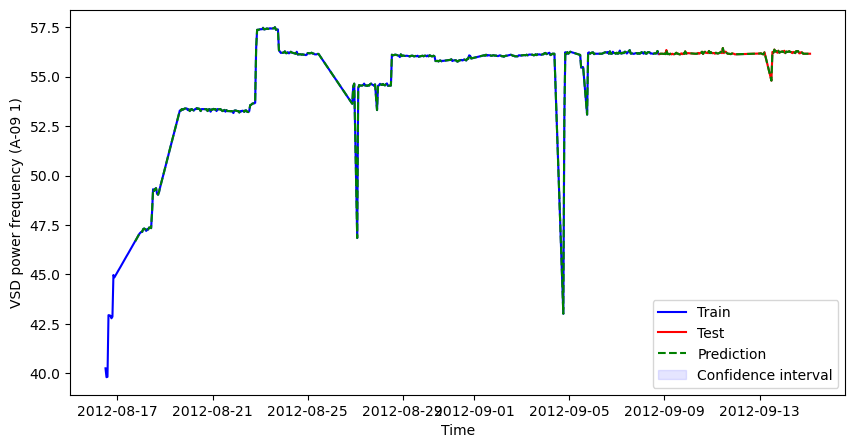

In [16]:
ye = y[nt:]
xe = x.shift(range(xord),fill_value=0).values[nt:]


fitted, confint = res.predict(n_periods=ye.size,X=xe, return_conf_int=True)
fitted_vals,confint_sample = res.predict_in_sample(return_conf_int=True,X=xt)


n = 30
plt.plot(yt,'b-')
plt.plot(ye,'r-')
plt.plot(ye.index,fitted,'g--')


plt.fill_between(ye.index,confint[:,0],confint[:,1],color='b',alpha=0.1)
plt.plot(yt.index[n:],fitted_vals[n:],'g--')
plt.fill_between(yt.index[n:],confint_sample[n:,0],confint_sample[n:,1],color='b',alpha=0.1)

plt.gcf().set_size_inches(10,5)

plt.xlabel("Time")
plt.ylabel(f'{data_name} ({well[0]})')

plt.legend(['Train', 'Test', 'Prediction','Confidence interval'])
